<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1043993/4020645430.py:68: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{\leftarrow\ {total_height:.2f}\\,mm\\ \\rightarrow}}$",
/tmp/ipykernel_1043993/4020645430.py:68: SyntaxWarning: invalid escape sequence '\l'
  f"$\mathbf{{\leftarrow\ {total_height:.2f}\\,mm\\ \\rightarrow}}$",


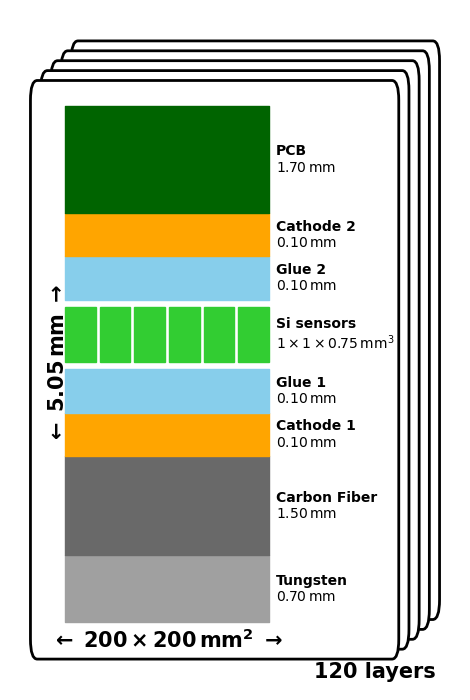

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plot_dir = "/home/llr/ilc/shi/code/Energy-Reco/Figures"

# 参数
width = 6.0                 
SiCells_plot = 6             
SiCells_gap_ratio = 0.1
num_layers = 120
transverse_size = 200        # mm
y_scale=0.4

# 层定义： (name, thickness (mm), color)
layers = [
    ("Tungsten", 0.7, "#A0A0A0"),   # 钨灰色
    ("Carbon Fiber", 1.5, "dimgray"),
    ("Cathode 1", 0.1, "orange"),
    ("Glue 1", 0.1, "skyblue"),
    ("Si sensors", 0.75, "limegreen"),
    ("Glue 2", 0.1, "skyblue"),
    ("Cathode 2", 0.1, "orange"),
    ("PCB", 1.7, "darkgreen"),
]

# 计算累积纵向位置
z = 0
positions = []
total_height = 0
for name, thick, color in layers:
    layer_height = (thick+1)*y_scale
    positions.append((z, z + layer_height, name, color, thick))
    z += layer_height
    total_height+= thick

# Sensitive 层小方块尺寸
total_gap = width * SiCells_gap_ratio
gap = total_gap / (SiCells_plot - 1)
block_width = (width - total_gap) / SiCells_plot

# 绘图
fig, ax = plt.subplots(figsize=(6, 8))

for z0, z1, name, color, thick in positions:
    if name == "Si sensors":
        block_height = (z1 - z0) * 0.8
        y_start = z0 + (z1 - z0 - block_height)/2
        for i in range(SiCells_plot):
            x = i * (block_width + gap)
            rect = patches.Rectangle(
                (x, y_start),
                block_width,
                block_height,
                color=color,
                alpha=1,    
                zorder=2
            )
            ax.add_patch(rect)
        ax.text(width + 0.2, z0 + (z1 - z0)/2,
                f"{name}\n$1\\times1\\times{thick:.2f}\\,\\mathrm{{mm}}^3$",
                va='center', ha='left', fontsize=10, fontweight='bold')
    else:
        ax.fill_betweenx([z0, z1], 0, width, color=color, alpha=1, zorder=2)
        ax.text(width + 0.2, (z0 + z1)/2,
                f"{name}\n${thick:.2f}\\,\\mathrm{{mm}}$",
                va='center', ha='left', fontsize=10, fontweight='bold',alpha=1,zorder=2)

ax.text(-0.5, z/2,
        f"$\mathbf{{\leftarrow\ {total_height:.2f}\\,mm\\ \\rightarrow}}$",
        va='center', ha='left', rotation=90, fontsize=15, fontweight='bold')


ax.text(width/2, -0.3,
        rf"$\mathbf{{\leftarrow\ {transverse_size}\times{transverse_size}\,mm^2\ \rightarrow}}$",
        va='bottom', ha='center', fontsize=15)


num_boxes = 5  # 叠加框的数量
for i in range(num_boxes):
    ax.add_patch(patches.FancyBboxPatch(
        (-1+i*0.3, -0.35 + i*0.1),  # 每次略微向上偏移
        width=width*1.8,
        height=total_height*1.15,
        fill=True,
        facecolor='white',
        alpha=1,  # 逐渐变透明
        edgecolor='black',
        linewidth=2,
        linestyle='-',
        boxstyle='round,pad=0.02,rounding_size=0.2',
        zorder=-i  # 保持在最底层
    ))

ax.text(width*1.8+0.1, -0.6, "120 layers", 
        ha='right', va='bottom', fontsize=15, fontweight='bold', color='black')


# 美化
ax.set_xticks([])
ax.set_yticks([])
#ax.set_xlim(-1.2, width + 1)
#ax.set_ylim(0, total_height)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.1)
plt.savefig(f"{plot_dir}/ECALGeo.pdf", dpi=300, bbox_inches='tight')
plt.show()

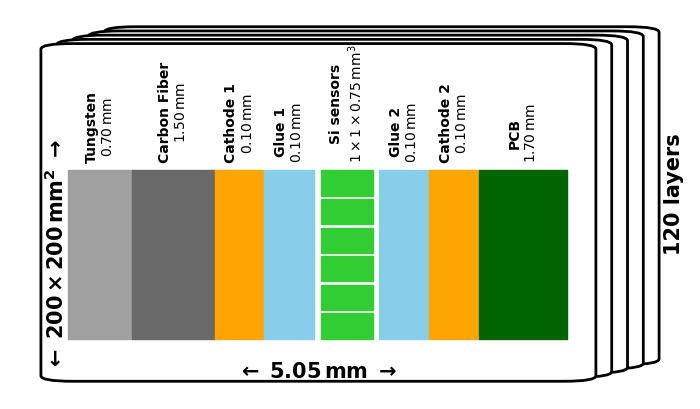

In [2]:
# 参数
height = 6.0                  # 垂直方向厚度
SiCells_plot = 6
SiCells_gap_ratio = 0.1
num_layers = 120
longitudinal_size = 200       # mm
x_scale = 0.15

# 层定义： (name, thickness (mm), color)
layers = [
    ("Tungsten", 0.7, "#A0A0A0"),
    ("Carbon Fiber", 1.5, "dimgray"),
    ("Cathode 1", 0.1, "orange"),
    ("Glue 1", 0.1, "skyblue"),
    ("Si sensors", 0.75, "limegreen"),
    ("Glue 2", 0.1, "skyblue"),
    ("Cathode 2", 0.1, "orange"),
    ("PCB", 1.7, "darkgreen"),
]

# 计算累积横向位置
x = 0
positions = []
total_length = 0
for name, thick, color in layers:
    layer_width = (thick + 2) * x_scale
    positions.append((x, x + layer_width, name, color, thick))
    x += layer_width
    total_length += thick

# Sensitive 层小方块尺寸
total_gap = height * SiCells_gap_ratio
gap = total_gap / (SiCells_plot - 1)
block_height = (height - total_gap) / SiCells_plot

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))

for x0, x1, name, color, thick in positions:
    if name == "Si sensors":
        block_width = (x1 - x0) * 0.8
        x_start = x0 + (x1 - x0 - block_width) / 2
        for i in range(SiCells_plot):
            y = i * (block_height + gap)
            rect = patches.Rectangle(
                (x_start, y),
                block_width,
                block_height,
                color=color,
                alpha=1,
                zorder=2
            )
            ax.add_patch(rect)
        ax.text((x0 + x1) / 2, height + 0.3,
                f"{name}\n$1\\times1\\times{thick:.2f}\\,\\mathrm{{mm}}^3$",
                va='bottom', ha='center', fontsize=10, fontweight='bold',rotation=90)
    else:
        ax.fill_between([x0, x1], 0, height, color=color, alpha=1, zorder=2)
        ax.text((x0 + x1) / 2, height + 0.3,
                f"{name}\n${thick:.2f}\\,\\mathrm{{mm}}$",
                va='bottom', ha='center', fontsize=10, fontweight='bold', alpha=1, zorder=2, rotation=90)

# 尺寸箭头
ax.text(x / 2, -0.8,
        rf"$\mathbf{{\leftarrow\ {total_length:.2f}\,mm\ \rightarrow}}$",
        va='top', ha='center', fontsize=15, fontweight='bold')

ax.text(-0., height / 2,
        rf"$\mathbf{{\leftarrow\ {longitudinal_size}\times{longitudinal_size}\,mm^2\ \rightarrow}}$",
        va='center', ha='right', rotation=90, fontsize=15)


# 叠加框 (表示层叠)
num_boxes = 5
for i in range(num_boxes):
    ax.add_patch(patches.FancyBboxPatch(
        (-0.15 + i * 0.1, -1.5+ i * 0.15),
        width=x * 1.1,
        height=height * 2,
        fill=True,
        facecolor='white',
        alpha=1,
        edgecolor='black',
        linewidth=2,
        linestyle='-',
        boxstyle='round,pad=0.02,rounding_size=0.2',
        zorder=-i
    ))

ax.text(x * 1.1+num_boxes * 0.1 - 0.2, height/2, "120 layers",
        ha='left', va='bottom', fontsize=15, fontweight='bold', color='black',rotation=90)

# 美化
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.subplots_adjust(left=0.1, right=0.95, top=0.85, bottom=0.2)
plt.show()
